In [2]:
from capstone_group4 import build_month_dataset
import os
# generate the dataset
# 2023.9 data
if os.path.exists("../files/2023.9.csv") == False:
    build_month_dataset(
            gse_path="../files/GSE_by_year/GSE_2023.csv",
            routes_path="../files/MBTA_GTFS/routes.txt",
            stops_path="../files/MBTA_GTFS/stops.txt",
            year=2023, month=9,
            out_path="../files/2023.9.csv"
        )
else:
    print("2023.9.csv already exists.")

# 2024.9 data
if os.path.exists("../files/2024.9.csv") == False:
    build_month_dataset(
            gse_path="../files/GSE_by_year/GSE_2024.csv",
            routes_path="../files/MBTA_GTFS/routes.txt",
            stops_path="../files/MBTA_GTFS/stops.txt",
            year=2024, month=9,
            out_path="../files/2024.9.csv"
        )
else:
    print("2024.9.csv already exists.")



2023.9.csv already exists.
2024.9.csv already exists.


In [3]:
# --- Step 1: Load & quick audit ---
import pandas as pd
import numpy as np


df = pd.read_csv("../files/2023.9.csv")


print("Shape:", df.shape)
print(df.head(8))


print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes.astype(str))


na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("\nTop 12 columns by missing count:\n", na_counts.head(12))
print("\nTop 12 columns by missing %:\n", na_pct.head(12))


if "gated_entries" in df.columns:
    print("\n'gated_entries' describe():\n", df["gated_entries"].describe())

Shape: (91679, 30)
  service_date time_period station_name route_or_line  gated_entries  \
0   2023-09-30  (00:00:00)      Alewife      Red Line            2.0   
1   2023-09-30  (00:00:00)      Airport     Blue Line           46.0   
2   2023-09-30  (00:00:00)     Aquarium     Blue Line           86.0   
3   2023-09-30  (00:00:00)    Arlington    Green Line           55.0   
4   2023-09-30  (00:00:00)     Assembly   Orange Line           16.0   
5   2023-09-30  (00:00:00)     Back Bay   Orange Line           92.0   
6   2023-09-30  (00:00:00)    Beachmont     Blue Line            1.0   
7   2023-09-30  (00:00:00)      Bowdoin     Blue Line           17.0   

       stop_id  hour_of_day  day_of_week  is_weekend  month  ...  \
0  place-alfcl            0            5           1      9  ...   
1  place-aport            0            5           1      9  ...   
2  place-aqucl            0            5           1      9  ...   
3  place-armnl            0            5           1      9 

In [4]:
# --- Step 2: Feature preparation ---


import numpy as np
import pandas as pd

raw = df["service_date"]


num1 = pd.to_numeric(raw, errors="coerce")

digits = raw.astype(str).str.extract(r"(\d{5,})")[0]
num2 = pd.to_numeric(digits, errors="coerce")


excel_serial = num1.fillna(num2)


dt_from_serial = pd.to_datetime("1899-12-30") + pd.to_timedelta(excel_serial, unit="D")


dt_generic = pd.to_datetime(raw, errors="coerce")


df["service_date"] = dt_from_serial.fillna(dt_generic)

df["day_of_week"] = df["service_date"].dt.dayofweek
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

print("Unique day_of_week values:", sorted(df["day_of_week"].dropna().unique()))

def parse_hour(tp):
    if pd.isna(tp):
        return np.nan
    s = str(tp).strip().strip("()")
    try:
        return int(s.split(":")[0])
    except:
        return np.nan

if "hour_of_day" not in df.columns:
    df["hour_of_day"] = df["time_period"].map(parse_hour)


df["day_of_week"] = df["service_date"].dt.dayofweek  # 0=Mon ... 6=Sun
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)


def assign_group(x):
    x = str(x).lower()
    if   "red"    in x: return "Red"
    elif "orange" in x: return "Orange"
    elif "blue"   in x: return "Blue"
    elif "green"  in x: return "Green"
    elif "silver" in x: return "Silver"
    elif "commuter" in x or "rail" in x: return "Commuter Rail"
    elif "bus" in x: return "Bus"
    elif "ferry" in x: return "Ferry"
    else: return "Other/Unknown"

if "route_group" not in df.columns:
    df["route_group"] = df["route_or_line"].map(assign_group)


df["rush_hour_flag"] = df["hour_of_day"].isin([7,8,16,17,18]).astype(int)


needed = ["gated_entries","route_group","is_transfer_station","hour_of_day","day_of_week","is_weekend","rush_hour_flag"]
print("\nColumns ready for EDA:", [c for c in needed if c in df.columns])


# df.to_csv("mbta_2023_09_ready.csv", index=False)
# print("Saved: mbta_2023_09_ready.csv")


Unique day_of_week values: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]

Columns ready for EDA: ['gated_entries', 'route_group', 'is_transfer_station', 'hour_of_day', 'day_of_week', 'is_weekend', 'rush_hour_flag']


                    mean         std  count
route_group                                
Red            88.123855  162.816956  26879
Orange         84.250619   92.612067  24413
Blue           70.761032   84.155428  14658
Green          64.435871   88.661799  20762
Other/Unknown  60.378955   54.435042   1237
Silver         41.174960   44.285742   3730


C:\Users\HUANG\AppData\Local\Temp\ipykernel_14980\1872798017.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=line_stats.reset_index(),


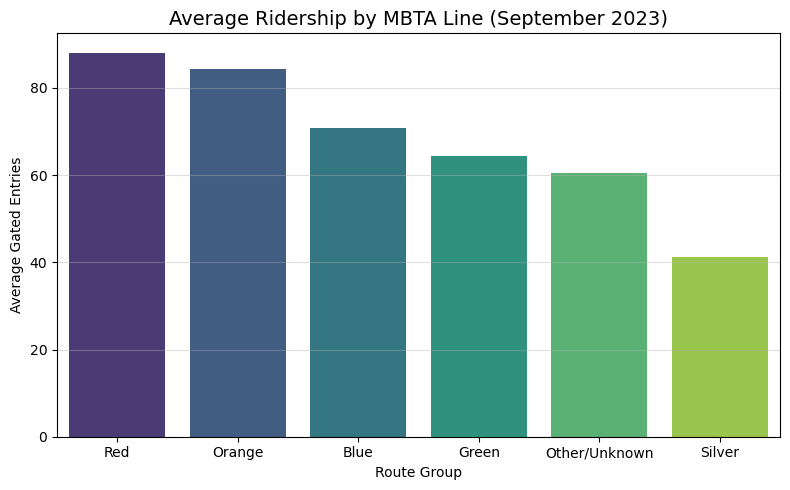

In [5]:
# Question 1
# Step 1 Combine data
import matplotlib.pyplot as plt
import seaborn as sns


line_stats = (
    df.groupby("route_group")["gated_entries"]
      .agg(["mean", "std", "count"])
      .sort_values("mean", ascending=False)
)
print(line_stats)
# Step 2
plt.figure(figsize=(8, 5))
sns.barplot(data=line_stats.reset_index(),
            x="route_group", y="mean",
            palette="viridis")

plt.title("Average Ridership by MBTA Line (September 2023)", fontsize=14)
plt.xlabel("Route Group")
plt.ylabel("Average Gated Entries")
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()



C:\Users\HUANG\AppData\Local\Temp\ipykernel_14980\4245970240.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_transfer_station", y="gated_entries", ax=ax1,
C:\Users\HUANG\AppData\Local\Temp\ipykernel_14980\4245970240.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_transfer_station", y="gated_entries", ax=ax2,


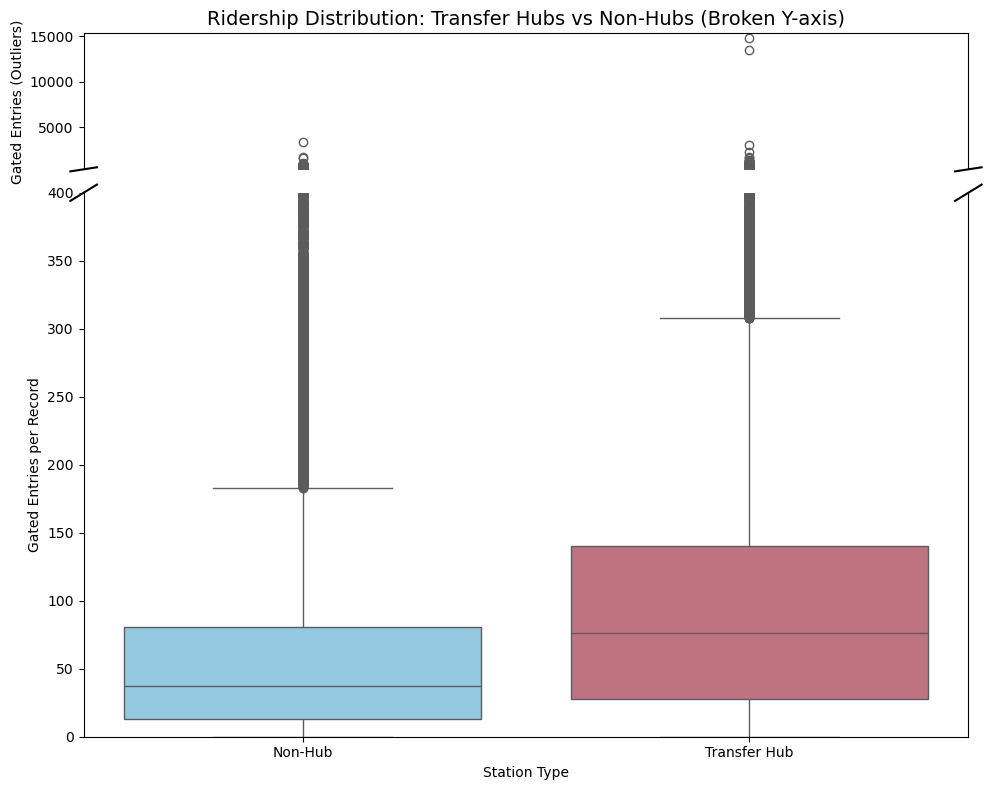

T-statistic: 43.268,  p-value: 0.0000


In [6]:
# Question 2
import matplotlib.pyplot as plt
import seaborn as sns


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                               gridspec_kw={'height_ratios': [1, 4]})


sns.boxplot(data=df, x="is_transfer_station", y="gated_entries", ax=ax1,
            palette=["#88CCEE", "#CC6677"])
ax1.set_ylim(400, df["gated_entries"].max() + 500)
ax1.set_title("Ridership Distribution: Transfer Hubs vs Non-Hubs (Broken Y-axis)", fontsize=14)
ax1.set_xlabel("")
ax1.set_ylabel("Gated Entries (Outliers)")


sns.boxplot(data=df, x="is_transfer_station", y="gated_entries", ax=ax2,
            palette=["#88CCEE", "#CC6677"])
ax2.set_ylim(0, 400)
ax2.set_xlabel("Station Type")
ax2.set_ylabel("Gated Entries per Record")

ax1.xaxis.set_visible(False)


ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

plt.xticks([0, 1], ["Non-Hub", "Transfer Hub"])
plt.tight_layout()
plt.show()
# t-test
from scipy.stats import ttest_ind

hub = df.loc[df["is_transfer_station"] == 1, "gated_entries"]
nonhub = df.loc[df["is_transfer_station"] == 0, "gated_entries"]
t_stat, p_val = ttest_ind(hub, nonhub, equal_var=False)
print(f"T-statistic: {t_stat:.3f},  p-value: {p_val:.4f}")


Pivot shape: (24, 7)
Columns: ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_of_week       Mon       Tue       Wed        Thu        Fri        Sat  \
hour_of_day                                                                  
0            6.428728  7.491447  7.702950  11.321945  18.455924  18.045117   
1            2.129942  2.329993  1.950411   2.180908   3.217042   3.181825   
2            1.381725  2.929910  1.486732   1.372620   1.449658   1.342653   
3            1.046783  1.500000  4.555556   1.347826   1.235294   1.121212   
4            4.029825  4.399707  4.708967   4.254839   4.161960   2.029448   

day_of_week       Sun  
hour_of_day            
0            7.376625  
1            2.393000  
2            1.562141  
3            1.331789  
4            1.044833  


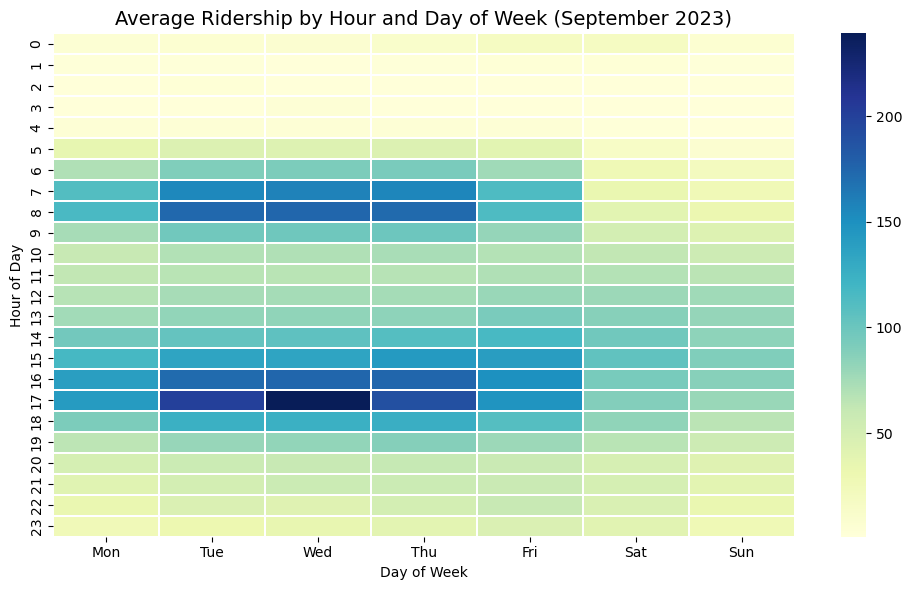

In [7]:
# Question 3
# pivot + heatmap (robust version) ----
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


tmp = df.loc[df["hour_of_day"].notna() & df["day_of_week"].notna()].copy()
tmp["hour_of_day"] = tmp["hour_of_day"].astype(int)
tmp["day_of_week"]  = tmp["day_of_week"].astype(int)


pivot_df = tmp.pivot_table(
    values="gated_entries",
    index="hour_of_day",
    columns="day_of_week",
    aggfunc="mean"
).sort_index(axis=0).sort_index(axis=1)


name_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
pivot_df = pivot_df.rename(columns={k: name_map[k] for k in pivot_df.columns if k in name_map})

print("Pivot shape:", pivot_df.shape)
print("Columns:", list(pivot_df.columns)[:10])
print(pivot_df.head())


plt.figure(figsize=(10,6))
sns.heatmap(pivot_df, cmap="YlGnBu", linewidths=0.3)
plt.title("Average Ridership by Hour and Day of Week (September 2023)", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()


CSV data:
   service_date time_period station_name route_or_line  gated_entries  \
0   2023-09-30  (00:00:00)      Alewife      Red Line            2.0   
1   2023-09-30  (00:00:00)      Airport     Blue Line           46.0   
2   2023-09-30  (00:00:00)     Aquarium     Blue Line           86.0   
3   2023-09-30  (00:00:00)    Arlington    Green Line           55.0   
4   2023-09-30  (00:00:00)     Assembly   Orange Line           16.0   

       stop_id  hour_of_day  day_of_week  is_weekend  month  ...  \
0  place-alfcl            0            5           1      9  ...   
1  place-aport            0            5           1      9  ...   
2  place-aqucl            0            5           1      9  ...   
3  place-armnl            0            5           1      9  ...   
4  place-astao            0            5           1      9  ...   

      network_id  municipality parent_station  is_transfer_station  \
0  rapid_transit     Cambridge            NaN                    1   
1  rapi

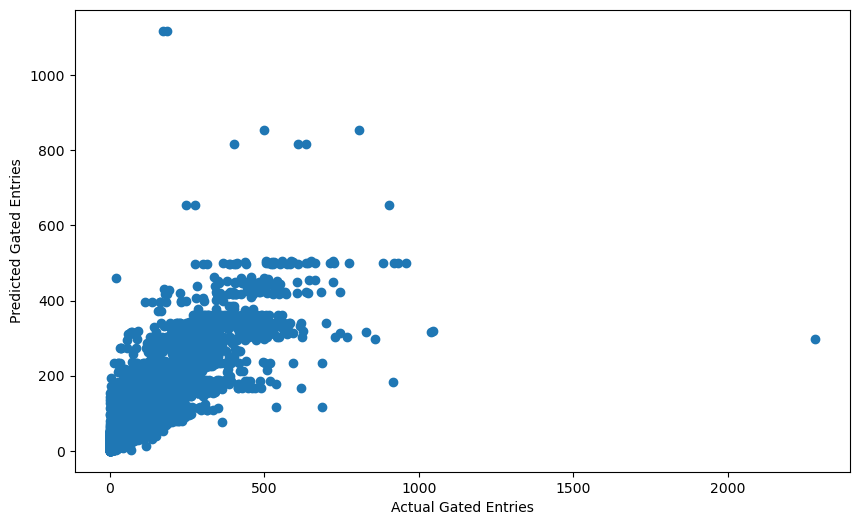

R²: 0.705 - MSE: 2773.773


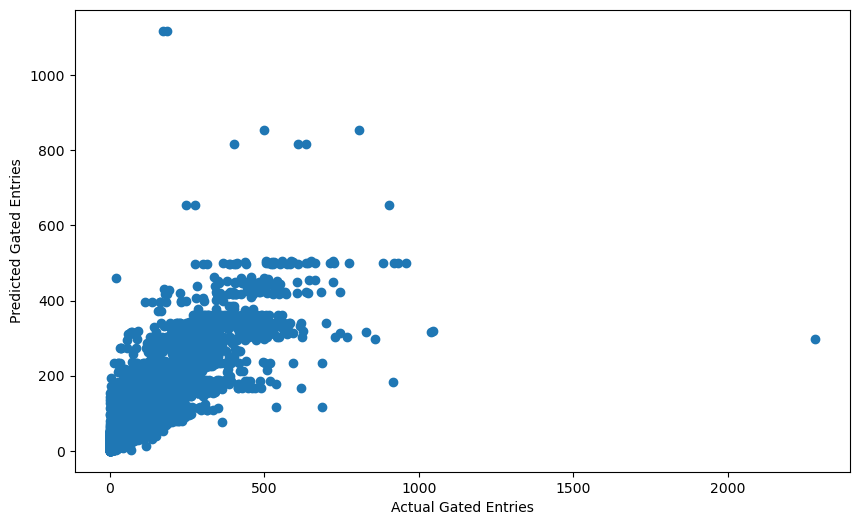

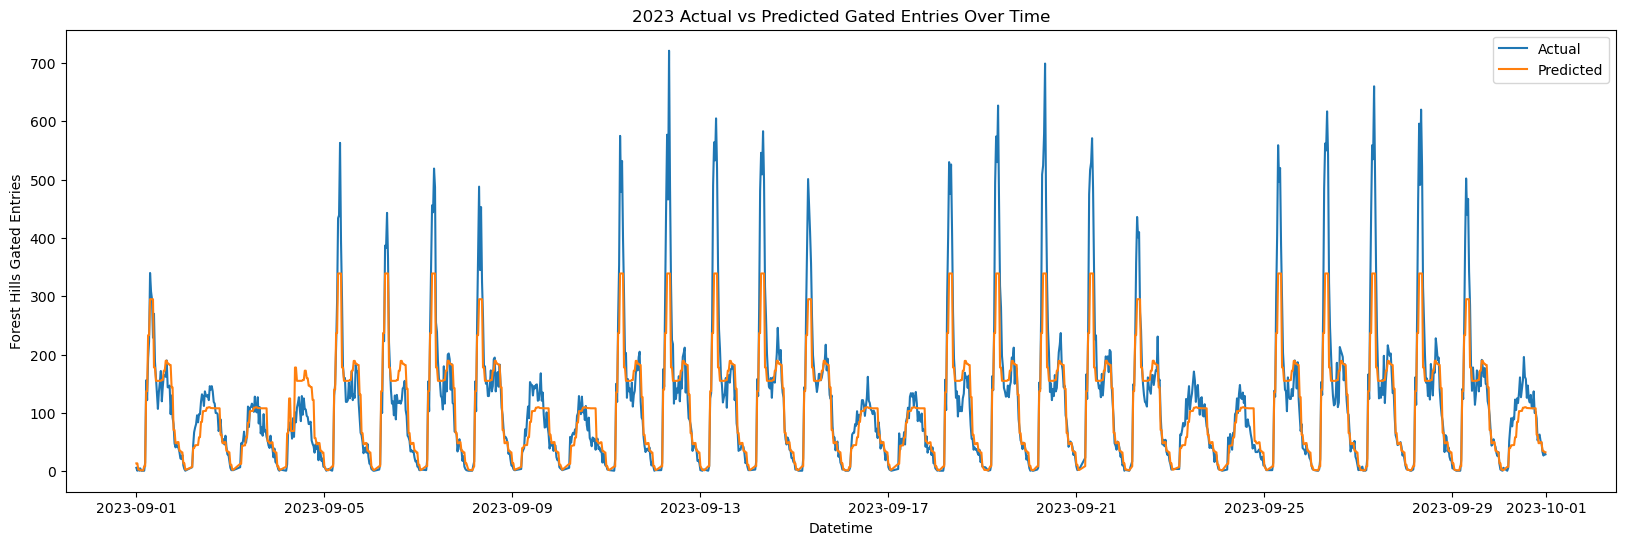

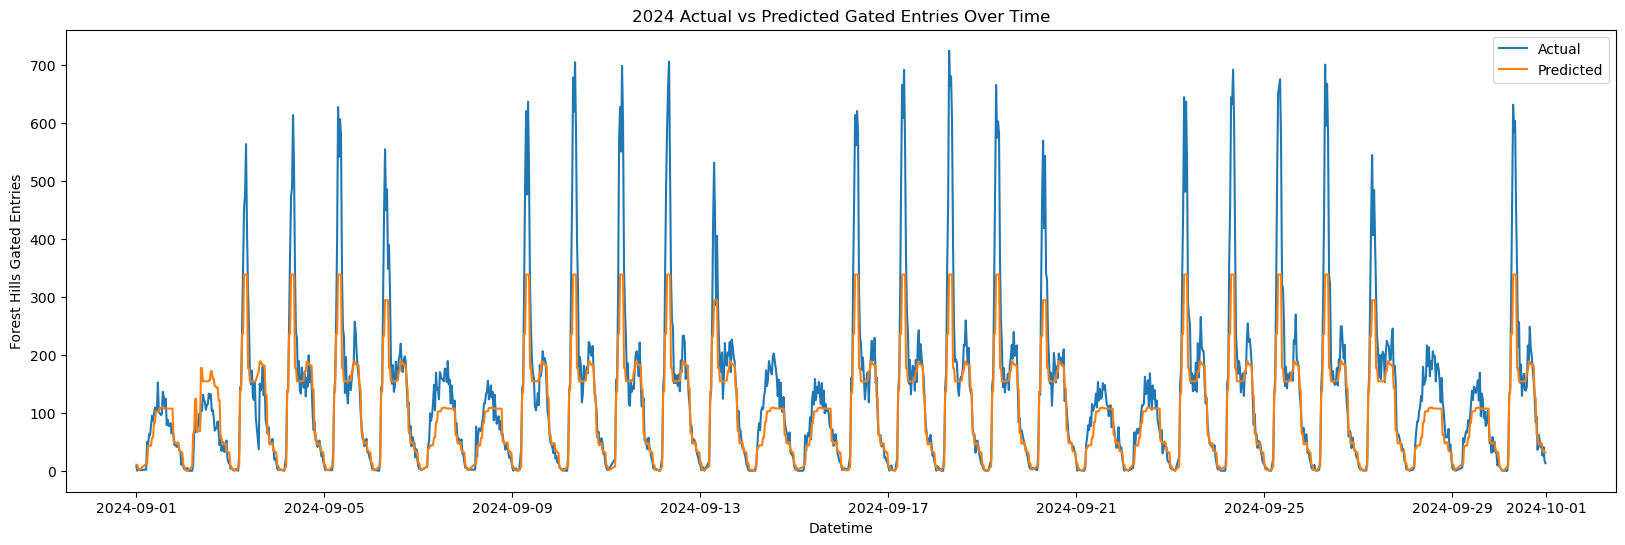

In [8]:
from capstone_group4 import read_data_csv
from dataset_clean import clean_data
from capstone_group4 import pred_data_randomForest
import matplotlib.pyplot as plt
import seaborn as sns



# get data
data = read_data_csv("../files/2023.9.csv")
data_2024 = read_data_csv("../files/2024.9.csv")

# clean data
pre_data = clean_data(data)
pred_data_2024 = clean_data(data_2024)

pre_data_with_pred, model = pred_data_randomForest(pre_data, pre_data)
pred_data_2024_with_pred, model = pred_data_randomForest(pre_data, pred_data_2024)

#2023 data comparation
fig_compare = plt.figure(figsize=(20, 6))
fh_data = pre_data.loc[pre_data['station_name'] == 'Forest Hills']
fh_pred_data = pre_data_with_pred.loc[pre_data_with_pred['station_name'] == 'Forest Hills']
sns.lineplot(data = fh_data, x="time", y="gated_entries", label="Actual")
sns.lineplot(data = fh_pred_data, x="time", y="predicted_gated_entries", label="Predicted")
plt.xlabel("Datetime")
plt.ylabel("Forest Hills Gated Entries")
plt.title("2023 Actual vs Predicted Gated Entries Over Time")
plt.legend()
plt.show()

#2024 data comparation
fig_compare2 = plt.figure(figsize=(20, 6))
fh_data2 = pred_data_2024.loc[pred_data_2024['station_name'] == 'Forest Hills']
fh_pred_data2 = pred_data_2024_with_pred.loc[pred_data_2024_with_pred['station_name'] == 'Forest Hills']
sns.lineplot(data = fh_data2, x="time", y="gated_entries", label="Actual")
sns.lineplot(data = fh_pred_data2, x="time", y="predicted_gated_entries", label="Predicted")
plt.xlabel("Datetime")
plt.ylabel("Forest Hills Gated Entries")
plt.title("2024 Actual vs Predicted Gated Entries Over Time")
plt.legend()
plt.show()

   hour_of_day route_or_line route_color  predicted_entries
0            0     Blue Line     #003DA5        7567.208598
1            0   Orange Line     #ED8B00       10230.637369
2            0      Red Line     #DA291C        9748.914359
3            1     Blue Line     #003DA5        1051.191968
4            1   Orange Line     #ED8B00        1527.419124


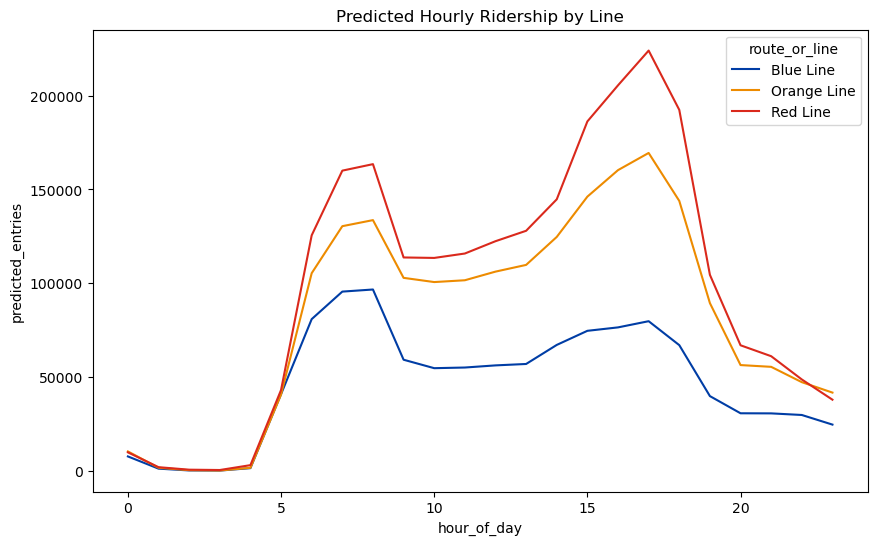

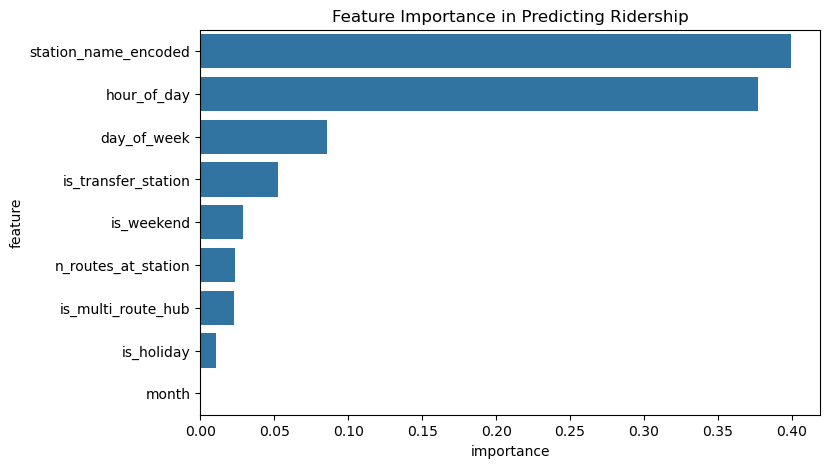

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Visualize predicted ridership patterns across all routes/lines
plt.figure(figsize=(10,6))
new_data = pre_data[['station_name_encoded','hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday','is_transfer_station','n_routes_at_station','is_multi_route_hub']]
pre_data['predicted_entries'] = model.predict(new_data)
pic_data = pre_data.groupby(['hour_of_day', 'route_or_line','route_color'])['predicted_entries'].sum().reset_index()
print(pic_data.head())
sns.lineplot(x='hour_of_day', y='predicted_entries', hue='route_or_line', palette=pic_data.set_index('route_or_line')['route_color'].to_dict(), data=pic_data)
plt.title('Predicted Hourly Ridership by Line')
plt.show()

# Feature importance analysis
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': new_data.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)
# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance in Predicting Ridership')
plt.show()



c:\Users\HUANG\DownloadApp\Anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\HUANG\DownloadApp\Anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


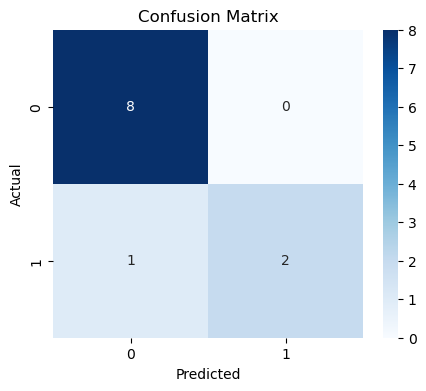

Classification Model Evaluation Metrics:
Accuracy: 0.9091
F1 Score: 0.8000
Precision: 1.0000
Recall: 0.6667


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split

# Aggregate data at the station
station_data = pre_data.copy()
station_data = station_data.groupby('station_name').agg({
    'gated_entries': ['max','min','std'],
    'is_transfer_station': 'max',
    'n_routes_at_station': 'max',
    'is_multi_route_hub': 'max'
    }).reset_index()


# Define features and target
x = station_data[['gated_entries','n_routes_at_station','is_multi_route_hub']]
y = station_data["is_transfer_station"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

# Define individual model
models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
]
# Create Voting Classifier
voting_model = VotingClassifier(estimators=models, voting='hard')
voting_model.fit(X_train, y_train)

y_pred = voting_model.predict(X_test)

# Confusion Matrix and Classification Report
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Model Report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
print("Classification Model Evaluation Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")


